# Homework 6
This homework builds on the effective visualization workshop with the Star Trek data. Below is what we completed in class. Output is suppressed for readability, but you can remove the supression on your code if you'd like.

In [1]:
invisible({
suppressPackageStartupMessages(library(tidyverse))

# Get the data.
dialogs <- read_csv(
  "https://raw.githubusercontent.com/Vincent-Toups/bios512/fcbc65a2696c7cff80d0f6ed1dd5c97abf0ef800/effective-visualization/source_data/tng.csv",
  show_col_types = FALSE
)
head(dialogs, 10) # Showing first 10 observations

# Checkout the data.
names(dialogs)
dialogs %>% group_by(character) %>% tally() %>% arrange(desc(n))
dialogs %>% mutate(dialog_length=str_length(dialog)) %>% group_by(character) %>% summarize(mean_dialog_length = mean(dialog_length)) %>% arrange(desc(mean_dialog_length))

# Fix weird data.
dialogs %>% filter(character=="BEVERLY'S")

dialogs_fixed <- dialogs %>%
  mutate(
    character = str_replace_all(character, "'S.*$", ""),
    character = str_replace_all(character, " VOICE", ""),
    character = str_replace_all(character, "\\.", ""),
    character = str_replace_all(character, "'", ""),
    character = str_replace_all(character, "S COM", ""),
    character = str_replace_all(character, " COM", ""),
    dialog_length = str_length(dialog)
  ) %>%
  filter(character %in% unlist(str_split("PICARD RIKER DATA TROI BEVERLY WORF WESLEY GEORDI", " ")))

dialogs_fixed %>% group_by(character) %>% summarize(mean_dialog_length = mean(dialog_length), std_dialog_length=sd(dialog_length)) %>% arrange(desc(mean_dialog_length))

dialog_len_per_ep <- dialogs_fixed %>% group_by(character, episode_number) %>% summarize(mean_dialog_length = mean(dialog_length), std_dialog_length=sd(dialog_length), .groups = "drop") %>% arrange(desc(mean_dialog_length))

dialog_len_per_ep

# Plot the data.
ggplot(dialogs_fixed) + geom_density(aes(x=dialog_length))

for_factor <- dialog_len_per_ep %>% group_by(character) %>% summarise(m=mean(mean_dialog_length)) %>% arrange(desc(m))
ggplot(dialog_len_per_ep, aes(factor(character,for_factor$character), mean_dialog_length)) + geom_boxplot()

dialog_len_per_ep <- dialogs_fixed %>% 
    group_by(character, episode_number) %>% 
    summarize(mean_dialog_length = mean(dialog_length), dialog_count=n(), .groups = "drop") %>% 
    arrange(desc(mean_dialog_length))

ggplot(dialog_len_per_ep, aes(dialog_count, mean_dialog_length)) + geom_point(aes(color=character)) + facet_wrap(~character)
})

## Question 1
In class, we left off on the plot below, which shows the distribution of dialog count by mean dialog length, where each point represents an episode. Interpret these results. How can we tell the character's role in the story by their plot?

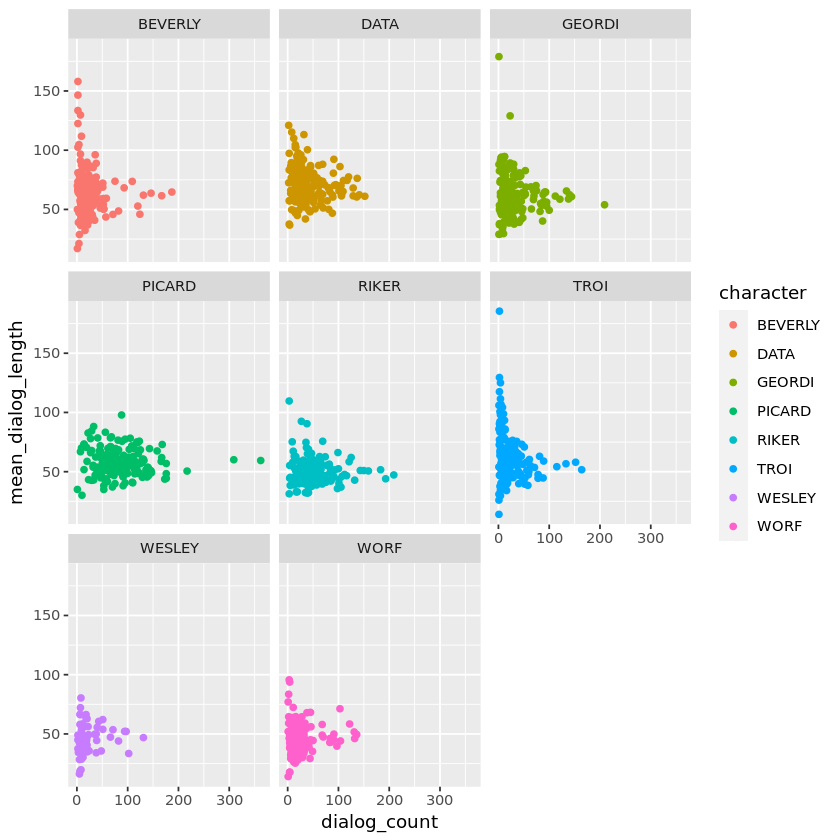

In [4]:
ggplot(dialog_len_per_ep, aes(dialog_count, mean_dialog_length)) + 
    geom_point(aes(color=character)) + 
    facet_wrap(~character)

In [6]:
The plot above shows how the appearance of the characters in episodes vary. Eg: characters like Picard, Data, Beverly, Troi appear in many episodes while characters
like Weasly, Wolf and Riker has comparitively low episodes. Similarly, Picard seem to have higher average number of dialogue per episode while it exceeding in some of
episodes. Similarly, Troi seem to have longer dialogues in some episodes and shorter in some. Beverly also seem to have longer dialogues in some of the episodes. This
can help us find the main characters based on the number of episodes they appeared, average number of dialogues per episodes and the length of their dialogue. 

ERROR: Error in parse(text = x, srcfile = src): <text>:1:5: unexpected symbol
1: The plot
        ^


## Question 2
#### a) Compare Beverly's mean dialog per episode vs. mean dialog count per episode from season 1 (episodes 102-126) to season 3 (episodes 149-174) in a table.  
*Hints*:  
-   First, use `filter()` to get - 1) the dialog from only Beverly's character and 2) the episodes within the ranges given.
-   Then, add a season variable using `mutate()` with `case_when()`.
-   To create the means per episode, after your `mutate()` step, you'll need to `group_by()` season and episode number, then you can do your `summarize()` step to get the means by episode. At the end of the `summary()` statement (inside the parenthesis), add `.groups="drop"`. 
-   Then, to get the mean of means, you'll do the same as above, but only grouping by season. 

In [7]:
library(tidyverse)
library(stringr)
library(tidyr)

In [5]:
# Filter Beverly and episodes 
beverly_dialogue <- dialogs_fixed %>% 
filter (character == "BEVERLY", 
        (episode_number >=102 & episode_number <=126) | 
        (episode_number >=149 & episode_number <=174)) %>% 
mutate(season = case_when (episode_number >=102 & episode_number <=126 ~ "Season 1 (102-126)", 
                           episode_number >=149 & episode_number <= 174 ~ "Season 3 (149-174)", 
                           TRUE ~ NA_character_ )) 
# Mean dialogue length and counts per episode 
beverly_per_ep <- beverly_dialogue %>% 
group_by(season, episode_number)%>% 
summarize( mean_dialog_length=mean (dialog_length, na.rm = TRUE), 
          dialog_count = n(), .groups = "drop" ) 

#Mean dialogue per episode 
beverly_mean <-beverly_per_ep %>%
group_by (season) %>% 
summarize ( mean_of_means = mean(mean_dialog_length, na.rm =TRUE), 
           mean_dialogue_count = mean (dialog_count, na.rm = TRUE), 
           n_episodes = n(), 
           .groups = "drop" ) 

beverly_per_ep 
beverly_mean

season,episode_number,mean_dialog_length,dialog_count
<chr>,<dbl>,<dbl>,<int>
Season 1 (102-126),102,56.74194,31
Season 1 (102-126),103,58.82222,45
Season 1 (102-126),104,55.64706,17
Season 1 (102-126),105,69.20000,10
Season 1 (102-126),106,57.54545,11
Season 1 (102-126),107,36.60000,10
Season 1 (102-126),108,43.63158,57
Season 1 (102-126),109,45.73333,30
Season 1 (102-126),110,50.25000,52


season,mean_of_means,mean_dialogue_count,n_episodes
<chr>,<dbl>,<dbl>,<int>
Season 1 (102-126),56.48460,25.40,25
Season 3 (149-174),67.04817,19.64,25


#### b) In class, we talked about this character saying the actress has stated that after she was fired and rehired, the writers began giving her storylines that made her feel like a male character. How is this reflected in our table?

In [ ]:
Beverly in season one had average of 25 lines per episode and with the average length of dialog, 56. After being fired and rehired, her dialogue count decreased to ~20. 
However the average dialogue length increased to 67. This shows that even though the number of dialogues per episode decreased for her, she had more substantial dialogues
giving her importance as the male characters with more dialogue weight. 

## Question 3
Let's compare the vocabulary richness (unique words / total words) of each character. 
#### a) Tokenize dialog into words, remove punctuation, convert to lowercase. Then filter out the stop words in the list below (from https://gist.github.com/sebleier/554280).
*Hint*: Here's a template for that this step should look like:
```
tokens <- YOUR_DATASET %>%
  # Split each dialog into words
  mutate(word_list = str_split(DIALOG_COLUMN, "\\s+")) %>%
  
  # Unnest the list column so each word is a row
  unnest(word_list) %>%
  
  # Clean words
  mutate(
    word = str_remove_all(word_list, "[[:punct:]]"),  # Remove punctuation
    word = str_to_lower(word)                         # Convert to lowercase
  ) %>%
  
  # Remove empty strings and stopwords
  filter(word != "", !word %in% STOPWORDS)
```

In [9]:
stop_words <- c(
  "i","me","my","myself","we","our","ours","ourselves","you","your","yours","yourself",
  "yourselves","he","him","his","himself","she","her","hers","herself","it","its","itself",
  "they","them","their","theirs","themselves","what","which","who","whom","this","that",
  "these","those","am","is","are","was","were","be","been","being","have","has","had",
  "having","do","does","did","doing","a","an","the","and","but","if","or","because","as",
  "until","while","of","at","by","for","with","about","against","between","into","through",
  "during","before","after","above","below","to","from","up","down","in","out","on","off",
  "over","under","again","further","then","once","here","there","when","where","why","how",
  "all","any","both","each","few","more","most","other","some","such","no","nor","not",
  "only","own","same","so","than","too","very","s","t","can","will","just","don","should","now"
)

#Tokenize dialog
tokens<-dialogs_fixed %>%

#Split dialog into words
mutate(word_list = str_split(dialog, "\\s+")) %>%

# Unnest the list column so each word is a row
  unnest(word_list) %>%

 # Clean words
  mutate(
    word = str_remove_all(word_list, "[[:punct:]]"),  # Remove punctuation
    word = str_to_lower(word)                         # Convert to lowercase
  ) %>%

  # Remove empty strings and stopwords
  filter(word != "", !word %in% stop_words)

head (tokens, 20)


episode_number,character,dialog,dialog_length,word_list,word
<dbl>,<chr>,<chr>,<int>,<chr>,<chr>
102,PICARD,"Captain's log, stardate 42353.7. Our destination is planet Cygnus IV, beyond which lies the great unexplored mass of the galaxy.",128,Captain's,captains
102,PICARD,"Captain's log, stardate 42353.7. Our destination is planet Cygnus IV, beyond which lies the great unexplored mass of the galaxy.",128,"log,",log
102,PICARD,"Captain's log, stardate 42353.7. Our destination is planet Cygnus IV, beyond which lies the great unexplored mass of the galaxy.",128,stardate,stardate
102,PICARD,"Captain's log, stardate 42353.7. Our destination is planet Cygnus IV, beyond which lies the great unexplored mass of the galaxy.",128,42353.7.,423537
102,PICARD,"Captain's log, stardate 42353.7. Our destination is planet Cygnus IV, beyond which lies the great unexplored mass of the galaxy.",128,destination,destination
102,PICARD,"Captain's log, stardate 42353.7. Our destination is planet Cygnus IV, beyond which lies the great unexplored mass of the galaxy.",128,planet,planet
102,PICARD,"Captain's log, stardate 42353.7. Our destination is planet Cygnus IV, beyond which lies the great unexplored mass of the galaxy.",128,Cygnus,cygnus
102,PICARD,"Captain's log, stardate 42353.7. Our destination is planet Cygnus IV, beyond which lies the great unexplored mass of the galaxy.",128,"IV,",iv
102,PICARD,"Captain's log, stardate 42353.7. Our destination is planet Cygnus IV, beyond which lies the great unexplored mass of the galaxy.",128,beyond,beyond


#### b) Count unique words per character. Print a summary table with the following columns: character, total words, unique words, and vocabulary richness.  
*Hint*: Group by character, then use `summarize()` to get what you want. You'll use `n_distinct()` to get the unique word counts. Arrange in descending value of vocabulary richness.

In [10]:
library (dplyr)

#Unique words per character
char_vocab <- tokens %>%
group_by (character)%>%
summarize(
    total_words = n(),
    unique_words = n_distinct(word),
    vocab_richness = unique_words /total_words,
    .group = "drop"
    )%>%
arrange(desc(vocab_richness))

char_vocab


character,total_words,unique_words,vocab_richness,.group
<chr>,<int>,<int>,<dbl>,<chr>
WESLEY,7601,2291,0.3014077,drop
WORF,18820,4318,0.2294368,drop
TROI,19450,4187,0.2152699,drop
BEVERLY,22900,4875,0.2128821,drop
DATA,45462,8593,0.1890150,drop
GEORDI,31978,5465,0.1708987,drop
RIKER,41827,6458,0.1543979,drop
PICARD,79214,9272,0.1170500,drop


#### c) Plot total words versus vocab richness. 
-   Use the character names as the "points".
    -   *Hint*: Use `geom_text()` to add the character names as the points.
-   Do not include a legend.
    -   *Hint*: Use `theme()` to remove the legend.
-   Add a title and axis titles.
    -   *Hint*: Use `labs()` to add titles.

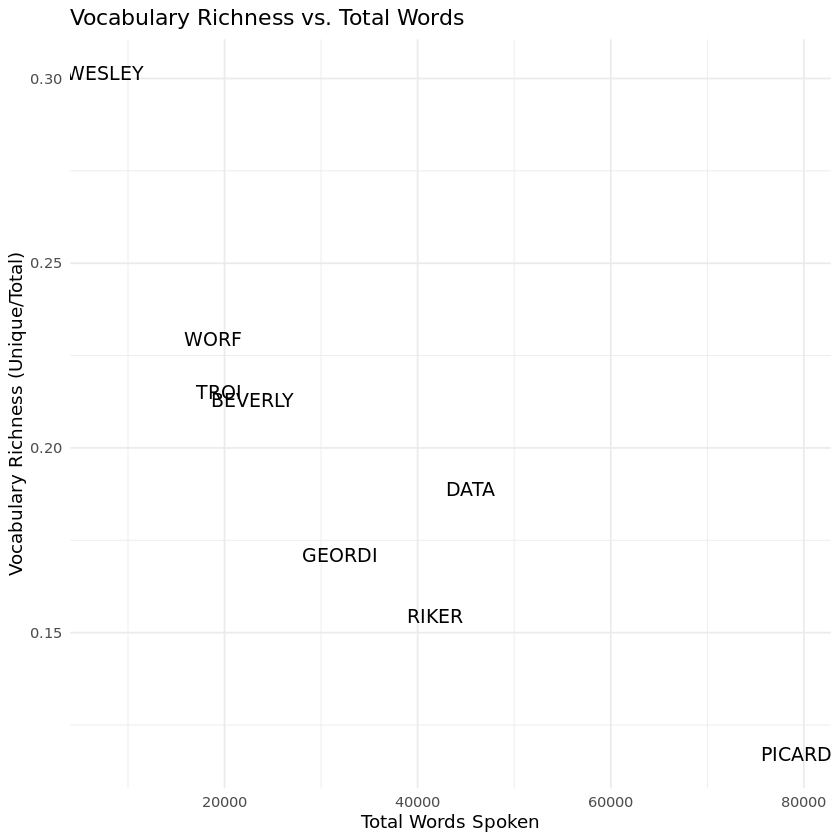

In [11]:
library(ggplot2)

ggplot(char_vocab, aes(x=total_words, y=vocab_richness,label=character)) +
geom_text(size =4) +
labs(
    title = "Vocabulary Richness vs. Total Words",
    x= "Total Words Spoken",
    y="Vocabulary Richness (Unique/Total)"
    )+ 
theme_minimal() +
theme (legend.position = "none")

#### d) Interpret these results. 

In [ ]:
The plot shows that the vocabulary richness tends to decrease with the increase in the total words. 
Weasley with comparatively few words has the highest richness sugegsting more varied vocab relative to his total speech. 
Picard has highest words spoken yet he has lowest richness. This maybe because frequent speakers often repeat their words. 
Other characters like Data, Geordi, Riker show medium vocab also with midium number of words. 

## Question 4
#### a) Find what episode Wesley left the show as a main character and state it explicitly. Meaning, find the first significant gap where he is not found in more than two episodes in a row. 
*Hint*: It's after season 3 (ended at episode 174), so you can filter out seasons 1-3 and print Wesley's dialog count per episode. Then, scan the table for the gap. 

In [17]:
#Filter Weasley lines
wesley_dialog <- dialogs_fixed %>%
filter(character =="WESLEY") %>%
group_by (episode_number) %>%
summarize(dialog_count = n(), .groups = "drop") %>%
arrange(episode_number)

#Counts after season 3, episode 174
wesley_after_s3 <- wesley_dialog %>%
filter(episode_number > 174)

wesley_after_s3

episode_number,dialog_count
<dbl>,<int>
175,18
176,6
177,9
178,6
179,38
181,2
183,94
206,131
219,71


In [ ]:
The first significant gap where he is not found in more than two episodes is after episode 183. 

#### b) After Wesley leaves the main cast, in which episodes does he make cameo appearances?

In [ ]:
After leaving the main cast, Wesley made cameo appearances in episodes 206, 219, 263 and 272.

#### c) Dig back into the data. Print:
-   Wesley's last piece of dialog before he left the main cast.
-   Wesley's last piece of dialog ever.  
  
*Hint*: To do this, you'll need to filter the `dialogs_fixed` data set to Welsey's lines and the episode number, and use `slice_tail(n = 1)` to get the last observation.

In [18]:
#Last dialogue before leaving episode 183
wesley_last_main <- dialogs_fixed %>%
filter(character == "WESLEY", episode_number ==183) %>%
slice_tail (n=1)

wesley_last_main

#Last dialog ever
wesley_last_ever <- dialogs_fixed %>%
filter(character =="WESLEY", episode_number == 272) %>%
slice_tail (n=1)

wesley_last_ever

episode_number,character,dialog,dialog_length
<dbl>,<chr>,<chr>,<int>
183,WESLEY,I can walk.,11


episode_number,character,dialog,dialog_length
<dbl>,<chr>,<chr>,<int>
272,WESLEY,"Good-bye, Mom.",14


In [ ]:
Wesley's last line before cameo was "I can walk." and his last line ever was "Good-bye, Mom."

## Question 5
Create a heatmap with `dialog_len_per_ep` showing mean dialog length per episode for each character. Sort the characters on the y-axis by their overall mean dialog length, with the lowest on top using a factor. Add a title and an axis title. 
*Hints*:
For the factor:
1. Compute overall mean (mean of mean) dialog length per character (`group_by()` then `summarize()`), and arrange the overall mean in ascending order. Add `pull(character)` to the end of this step so that you can use character as a factor in the next step. Store all of this in a new tibble.
2. Convert character to factor with this order. On `dialog_len_per_ep`, you'll use a mutate statement to add the factor `(mutate(character = factor(character, levels = DATAFROMHINT1))`.
3. Create heatmap using `geom_tile()`.
4. If you want nicer colors, you can add `scale_fill_viridis_c()` (or another color scale) to your ggplot statement. **Not required**, but fun to mess around with!

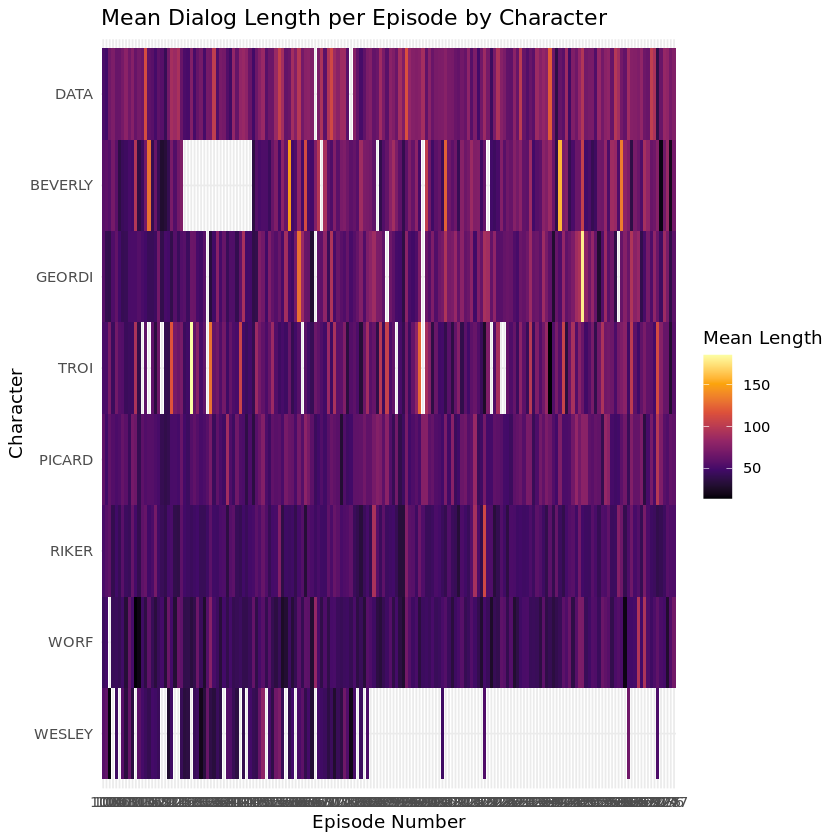

In [26]:
# Overall mean
char_order <- dialog_len_per_ep %>%
group_by(character) %>%
summarize(overall_mean = mean(mean_dialog_length, na.rm =TRUE), .groups = "drop") %>%
arrange (overall_mean)

#Reorder factor levels
dialog_len_per_ep <- dialog_len_per_ep %>%
mutate(character = factor(character, levels = char_order$character))

#Heatmap
ggplot(dialog_len_per_ep, aes (x=factor(episode_number),
                               y=character,
                               fill = mean_dialog_length)) +
geom_tile() +
scale_fill_viridis_c(option = "inferno")+
labs(title = "Mean Dialog Length per Episode by Character",
     x= "Episode Number",
     y="Character",
     fill="Mean Length") +
theme_minimal()